In [3]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
from cluster_functions import lowess

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = plt.cm.viridis
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')

In [7]:
aux = data.copy()
for cluster in df.index:
    aux.loc[cluster, 'age'] = df.loc[cluster, 'age']

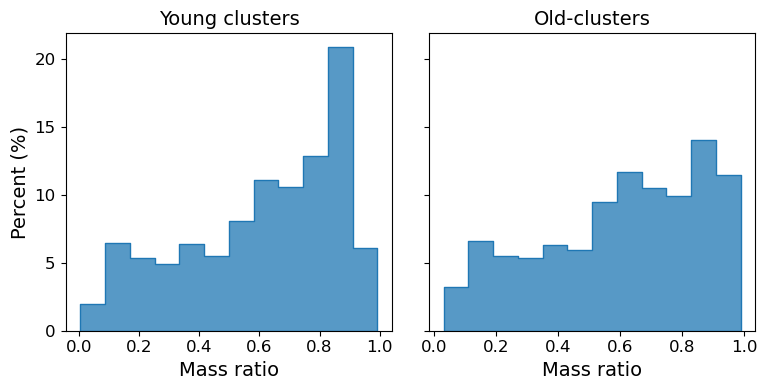

In [11]:
def classificar_idade(age):
    return 'Young clusters' if age < 8 else 'Old-clusters'
aux = aux[aux.q > 0]
aux['age_group'] = aux['age'].apply(classificar_idade)


fig, axs = plt.subplots(1,2, figsize=(8, 4), sharey=True)
age_order = ['Young clusters', 'Old-clusters']

for i, group in enumerate(age_order):
    subset = aux[aux.age_group == group]
    
    sns.histplot(data=subset, x='q',element='step', stat='percent',ax=axs[i], bins=12)
    axs[i].set_title(age_order[i], fontdict= font)
    axs[i].tick_params(labelsize=labelsize)
    axs[i].set_xlabel('Mass ratio', fontdict=font)


axs[0].set_ylabel('Percent (%)', fontdict=font)
plt.tight_layout()
#plt.savefig('Figures/hist_mass_ratio_mass.png', bbox_inches='tight', dpi=300)
plt.show()


In [9]:
#Compara as distribuições da razão de massa dos dois subconjuntos

young_q = aux[aux.age_group == 'Young clusters']['q']
old_q = aux[aux.age_group == 'Old-clusters']['q']

# Kolmogorov–Smirnov test
ks_stat, ks_p = ks_2samp(young_q, old_q)
print(f"KS test: stat = {ks_stat:.4f}, p = {ks_p:.4f}")
if ks_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')
    
# Mann–Whitney U test    
u_stat, u_p = mannwhitneyu(young_q, old_q, alternative='two-sided')
print(f"Mann–Whitney U test: U = {u_stat:.4f}, p = {u_p:.4f}")

if u_p<0.05:
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')

# Anderson–Darling test  
result = anderson_ksamp([young_q, old_q])
print(f"Anderson–Darling test: stat = {result.statistic:.4f}, p = {result.significance_level:.4f}")
if result.significance_level < 5: 
    print('Distribuições distintas\n')
else:
    print('Não há evidência de que são diferentes\n')



KS test: stat = 0.0526, p = 0.0000
Distribuições distintas

Mann–Whitney U test: U = 869351667.0000, p = 0.0022
Distribuições distintas

Anderson–Darling test: stat = 150.3530, p = 0.0010
Distribuições distintas



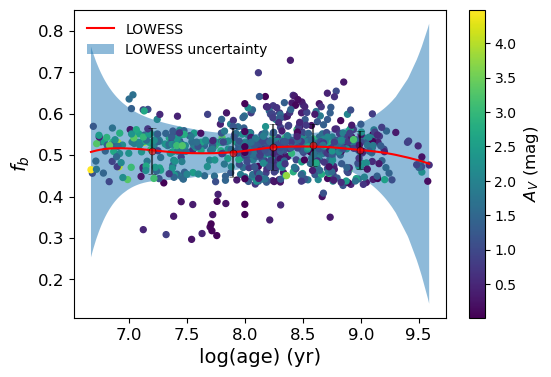

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))

X = df.age
Y = df.bin_frac_corr

order = np.argsort(X)
y_sm, y_std = lowess(X,Y, f=0.3)
ax.plot(X[order], y_sm[order], color='red', label='LOWESS')
ax.fill_between(X[order],
                np.where((y_sm[order] - 1.96*y_std[order])<0, 0 , y_sm[order] - 1.96*y_std[order]),
                np.where((y_sm[order] + 1.96*y_std[order])>1, 1 , y_sm[order] + 1.96*y_std[order]), 
                alpha=0.5, label='LOWESS uncertainty')

sc = ax.scatter(
        X,
        Y,
        c=df['Av'],
        cmap=palette,
        s=18
    )

subconjuntos = np.array_split(df.sort_values(by=X.name), 5)

x, y = [], []
x_err, y_err = [], []

for conjunto in subconjuntos:
    x.append(conjunto[X.name].mean())
    y.append(conjunto[Y.name].mean())
    y_err.append(conjunto[Y.name].std())
    
ax.errorbar(x,y,yerr = y_err, fmt='o',capsize=3, c='red', alpha=0.6, ms=5, ecolor = 'k', mec='k', mew=0.5,)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'$A_V$ (mag)', fontdict=font_cb)

ax.set_xlabel('log(age) (yr)', fontdict=font)
ax.set_ylabel(r'$f_b$', fontdict=font)
ax.tick_params(labelsize=labelsize)
ax.legend(frameon=False, loc = 'upper left')
plt.savefig('Figures/dist_fb_age.png', bbox_inches='tight', dpi=300)
plt.show()
